In [201]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import time
from IPython.display import display

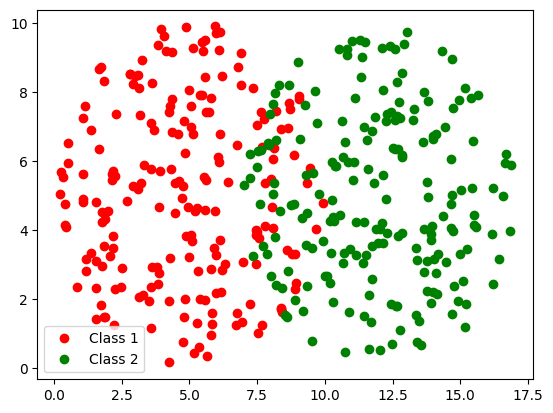

Classe 1 : 


array([[0.53465388, 6.52991716],
       [3.9345067 , 9.82450074],
       [3.14464854, 2.06055793],
       [8.19043683, 7.45478874],
       [1.37992728, 6.9196487 ],
       [5.39322803, 2.01834601],
       [4.04426248, 9.63136428],
       [5.96655421, 9.7176346 ],
       [1.65273081, 8.66661383],
       [6.77335519, 6.47559358],
       [9.45280422, 5.79493428],
       [1.57065587, 3.11213683],
       [1.82976749, 3.55810696],
       [4.89097827, 3.83420668],
       [4.3044649 , 5.77658912],
       [7.50991253, 7.06087111],
       [2.26994256, 2.29756999],
       [1.16157476, 7.59444107],
       [4.94989   , 4.67584602],
       [5.79051901, 2.87896831],
       [4.47810181, 4.4987369 ],
       [0.39088809, 4.13903964],
       [8.13317621, 6.38043625],
       [4.97597097, 3.22160237],
       [4.28197917, 7.59167475],
       [0.39518532, 4.7512082 ],
       [2.50636145, 2.9000308 ],
       [8.92789276, 2.47923605],
       [5.06286525, 7.0062905 ],
       [6.13663401, 3.72655676],
       [4.

In [202]:
def load_data(name):
    data = scipy.io.loadmat("dataNeurone/"+name)
    a = data['a']     # données
    y = data['y']     # yi = 1 si classe 1, 0 si classe 2
    
    id1 = np.where(y==1)[0]
    id2 = np.where(y==0)[0]
    return a[id1,:], a[id2,:]

classe1, classe2 = load_data("train_set.mat")

plt.plot(classe1[:,0], classe1[:,1], 'ro', label='Class 1')
plt.plot(classe2[:,0], classe2[:,1], 'go', label='Class 2')
plt.legend(loc='best')
plt.show()
print("Classe 1 : ")
display(classe1)

In [203]:
def fln(x, a1, a2):
    # Pour les points de la classe 1 :
    exp1 = np.exp(-np.clip(a1@x,-50,50))
    f1 = sum(np.log(1+exp1))
    v1 = exp1 / (1+exp1)
    g1 = -a1.T@v1
    
    # Pour les points de la classe 2 :
    exp2 = np.exp(np.clip(a2@x,-50,50))
    f2 = sum(np.log(1+exp2))
    v2 = exp2 / (1+exp2)
    g2 = a2.T@v2
    
    f = f1 + f2
    g = g1 + g2
    
    # f : la valeur de la fonction objectif en x
    # g : le vecteur gradient de f en x
    return f, g

In [204]:
#Cette fonction w1 vérifie si la condition de Wolfe 1 est vérifiée pour un alpha donné
def w1(fct, x, d, alpha, beta1=1e-4):
  f1,g1 = fct(x+alpha*d)
  f0,g0 = fct(x)
  return f1 <= f0+beta1*alpha*(d@g0) + 1e-9

#Cette fonction w2 vérifie si la condition de Wolfe 2 est vérifiée pour un alpha donné
def w2(fct, x, d, alpha, beta2=0.9):
  f1,g1 = fct(x+alpha*d)
  f0,g0 = fct(x)
  return d@g1 >= beta2*d@g0
    
def wolfebissetion(fct, x, d, alpha0):
  aleft = 0
  aright = np.inf
  alpha = alpha0
  while True:
    #print(f"Debut : aleft = {aleft}, aright = {aright}, et alpha = {alpha}")
    if w1(fct,x,d,alpha) and w2(fct,x,d,alpha):
      break
    if not w1(fct,x,d,alpha): #ça veut dire qu'on est trop loin
      aright = alpha          #on bouge la bornde de droite vers la gauche
      alpha = (aleft+aright)/2
    elif not w2(fct,x,d,alpha): #ça veut dire qu'on est trop loin
      aleft = alpha                #on bouge la borne de gauche vers la droite
      if aright < np.inf:
        alpha = (aleft+aright)/2
      else:
        alpha = 2*alpha #le 2 est arbitraire
    #print(f"Fin : aleft = {aleft}, aright = {aright}, et alpha = {alpha}")
  return alpha

In [205]:
def backtracking(fct, x, d, alpha=1):
    f0, g0 = fct(x)
    f1, g1 = fct(x+alpha*d)
    
    while f1>f0: # tant qu'on n'a pas trouvé un pas alpha où f(x+alpha*d)<f(x)
        alpha /= 2
        f1, g1 = fct(x+alpha*d)
    return alpha

def methGRADIENT(fct, x0, maxiter, maxtime, pas):
    start_time = time.time()
    temps = np.zeros(maxiter)
    fobj = np.zeros(maxiter)
    x = x0.copy()
    
    for i in range(maxiter):
        f, g = fct(x)
        d = -g
        
        if pas =="wolfe":
            alpha = wolfebissetion(fct,x,d,1)
        elif pas =="backtracking":
            alpha = backtracking(fct,x,d,1)
        
        x = x + alpha*d # calcul du nouvel itéré
        
        # stokage des inforamtiosn
        f, g = fct(x)
        fobj[i] = f
        temps[i] = time.time() - start_time
        
        if temps[i]>maxtime: break
    
    return x, fobj[:i+1], temps[:i+1]

def methGRADIENTACC(fct, x0, maxiter, maxtime, pas):
    start_time = time.time()
    temps = np.zeros(maxiter)
    fobj = np.zeros(maxiter)
    x = x0.copy()
    
    y = x0.copy()
    for i in range(maxiter):
        xprec = x.copy()
        f, g = fct(y)
        d = -g
        
        if pas =="wolfe":
            alpha = wolfebissetion(fct,y,d,1)
        elif pas =="backtracking":
            alpha = backtracking(fct,y,d,1)
        
        x = y + alpha*d # calcul du nouvel itéré
        
        y = x + (i/(i+3))*(x-xprec)
        # stokage des inforamtiosn
        f, g = fct(x)
        fobj[i] = f
        temps[i] = time.time() - start_time
        
        if temps[i]>maxtime: break
    
    return x, fobj[:i+1], temps[:i+1]

In [206]:
def optimisation(classe1, classe2, methode="grad", pas="wolfe", maxiter=10**4, maxtime=10):
    n1, m = classe1.shape
    n2, m = classe2.shape
    
    a1 = np.ones((n1, m+1))
    a2 = np.ones((n2, m+1))
    
    a1[:,1:] = classe1
    a2[:,1:] = classe2
    
    x0 = np.ones(m+1) # itéré initial
    if methode=="grad":
        x, f, t = methGRADIENT(lambda x: fln(x, a1, a2), x0, maxiter, maxtime, pas)
    elif methode=="gradacc":
        x, f, t = methGRADIENTACC(lambda x: fln(x, a1, a2), x0, maxiter, maxtime, pas)
    
    # x(taille m+1): dernier itéré calculé 
    # f : vecteur reprenant la valeur dela fonction objectif au cours des itérations
    # t : vecteur reprenant les instants où la fonction objectif a été évaluée
    return x, f, t      

In [207]:
classe1_petite,classe2_petite = load_data('train_set.mat')

xp_gd_wf, fp_gd_wf, tp_gd_wf = optimisation(classe1_petite, classe2_petite, methode='grad', pas='wolfe')
xp_gd_bt, fp_gd_bt, tp_gd_bt = optimisation(classe1_petite, classe2_petite, methode='grad', pas='backtracking')

xp_ga_wf, fp_ga_wf, tp_ga_wf = optimisation(classe1_petite, classe2_petite, methode='gradacc', pas='wolfe')
xp_ga_bt, fp_ga_bt, tp_ga_bt = optimisation(classe1_petite, classe2_petite, methode='gradacc', pas='backtracking')

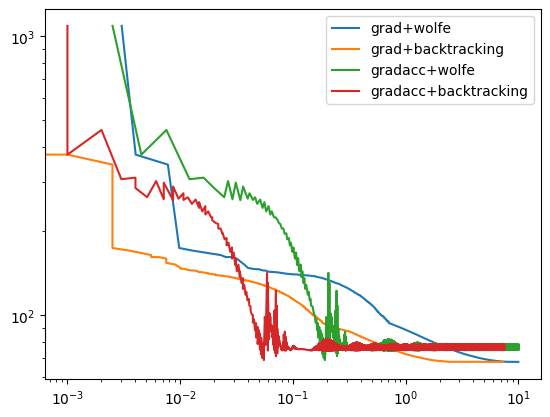

In [208]:
plt.loglog(tp_gd_wf,fp_gd_wf,label='grad+wolfe')
plt.loglog(tp_gd_bt,fp_gd_bt,label='grad+backtracking')
plt.loglog(tp_ga_wf,fp_ga_wf,label='gradacc+wolfe')
plt.loglog(tp_ga_bt,fp_ga_bt,label='gradacc+backtracking')
plt.legend(loc='best')

In [210]:
classe1_big, classe2_big = load_data('big_train_set.mat')

xb_ga_wf, fb_ga_wf, tb_ga_wf = optimisation(classe1_big, classe2_big, methode="grad", pas="wolfe", maxtime=30)
xb_ga_bt, fb_ga_bt, tb_ga_bt = optimisation(classe1_big, classe2_big, methode="grad", pas="backtracking",maxtime=30)

ValueError: setting an array element with a sequence.

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(tb_ga_wf, fb_ga_wf, 'b-', label='Fonction Objectif')
plt.title("Convergence de l'Optimisation (Grand Dataset)")
plt.xlabel("Temps (s)")
plt.ylabel("Valeur de la Fonction Objectif")
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
plt.loglog(tp_gd_wf,fp_gd_wf,label='grad+wolfe')
plt.loglog(tp_gd_bt,fp_gd_bt,label='grad+backtracking')
plt.loglog(tp_ga_wf,fp_ga_wf,label='gradacc+wolfe')
plt.loglog(tp_ga_bt,fp_ga_bt,label='gradacc+backtracking')
plt.legend(loc='best')